# 01 — Exploratory Data Analysis
**Defect Vision System**

Goal: generate the synthetic surface-inspection dataset and visually inspect what 'good' vs 'defective' images actually look like before training anything.

In [1]:
import sys
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)  # run from project root
from src.utils.config import load_config
from src.data.make_dataset import generate_image

config = load_config()

## Generate the dataset
Since there's no internet access to a real industrial defect dataset (e.g. MVTec AD), we generate a statistically realistic synthetic one: a brushed-metal base texture, with random scratches / dents / pit clusters drawn on the 'defective' class.

In [2]:
!python src/data/make_dataset.py

2026-06-28 20:46:36,652 | make_dataset | INFO | Generating 1200 'good' images -> /home/claude/defect-vision-system/data/raw/good


2026-06-28 20:46:38,465 | make_dataset | INFO | Generating 1200 'defective' images -> /home/claude/defect-vision-system/data/raw/defective


2026-06-28 20:46:40,484 | make_dataset | INFO | Done. Generated 2400 images across 2 classes at /home/claude/defect-vision-system/data/raw


In [3]:
!python src/data/prepare_splits.py

2026-06-28 20:46:41,890 | prepare_splits | INFO | good: train=840 val=180 test=180


2026-06-28 20:46:41,995 | prepare_splits | INFO | defective: train=840 val=180 test=180
2026-06-28 20:46:41,995 | prepare_splits | INFO | Split complete -> /home/claude/defect-vision-system/data/processed


## Visual sample — good vs defective
Let's look at a few examples from each class side by side.

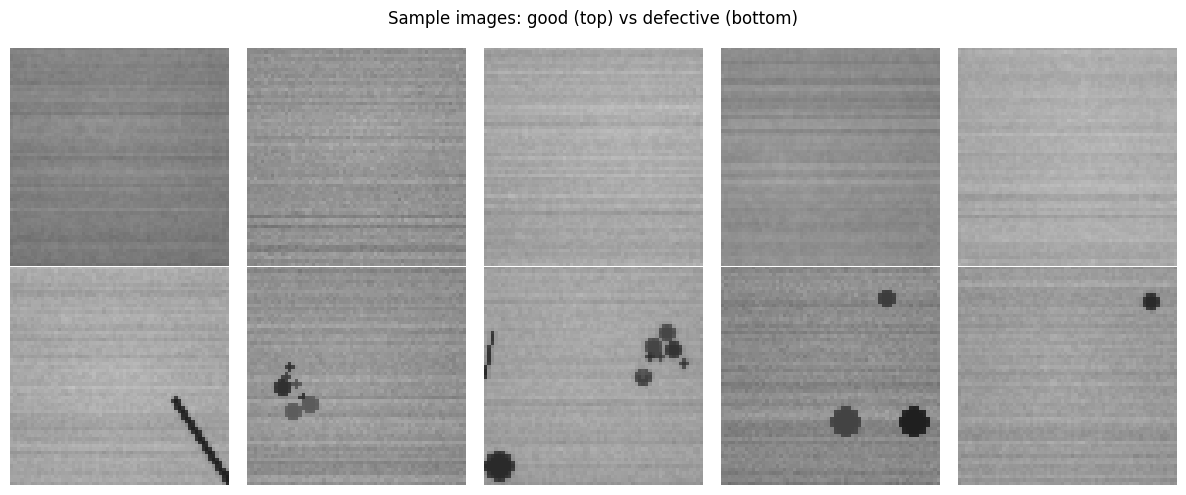

In [4]:
size = config['data']['image_size']
rng = np.random.default_rng(123)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for col in range(5):
    good_img = generate_image(size, defective=False, rng=rng)
    bad_img = generate_image(size, defective=True, rng=rng)
    axes[0, col].imshow(good_img)
    axes[0, col].axis('off')
    axes[1, col].imshow(bad_img)
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('good', fontsize=12)
axes[1, 0].set_ylabel('defective', fontsize=12)
fig.suptitle('Sample images: good (top) vs defective (bottom)')
plt.tight_layout()
plt.show()

**Observation:** 'good' images are a uniform brushed-metal texture with soft lighting gradients. 'defective' images have one or more dark scratches, dents, or pit clusters layered on top of the same base texture — these are exactly the low-level visual cues a CNN should learn to detect.

## Dataset size & class balance

In [5]:
processed_dir = Path(config['data']['processed_dir'])
for split in ['train', 'val', 'test']:
    for cls in config['data']['classes']:
        n = len(list((processed_dir / split / cls).glob('*.png')))
        print(f'{split:>6} / {cls:<10}: {n} images')

 train / good      : 840 images
 train / defective : 840 images
   val / good      : 180 images
   val / defective : 180 images
  test / good      : 180 images
  test / defective : 180 images


## Pixel intensity comparison
A quick sanity check: defective images should have darker minimum pixel values on average, since scratches/dents are drawn darker than the base surface.

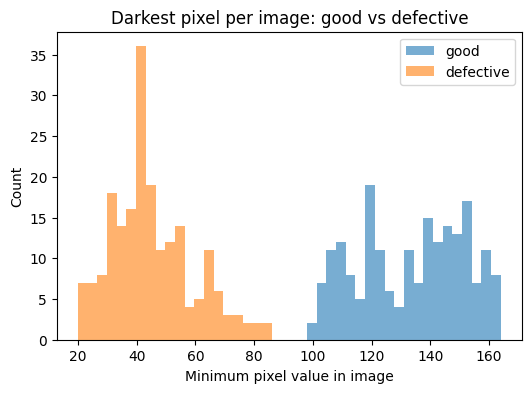

Mean darkest pixel - good: 133.5, defective: 45.0


In [6]:
raw_dir = Path(config['data']['raw_dir'])
good_mins, bad_mins = [], []
for f in list((raw_dir / 'good').glob('*.png'))[:200]:
    good_mins.append(np.array(Image.open(f)).min())
for f in list((raw_dir / 'defective').glob('*.png'))[:200]:
    bad_mins.append(np.array(Image.open(f)).min())

plt.figure(figsize=(6, 4))
plt.hist(good_mins, bins=20, alpha=0.6, label='good')
plt.hist(bad_mins, bins=20, alpha=0.6, label='defective')
plt.xlabel('Minimum pixel value in image')
plt.ylabel('Count')
plt.legend()
plt.title('Darkest pixel per image: good vs defective')
plt.show()

print(f'Mean darkest pixel - good: {np.mean(good_mins):.1f}, defective: {np.mean(bad_mins):.1f}')

**Observation:** defective images skew noticeably darker at their minimum pixel value — confirming the synthetic defects are visually learnable. Next step (`02_model_training.ipynb`): train a CNN to classify these images.